# NLP

Vamos a estudiar el dataset 'SMS Spam Collection Dataset', que contiene 5,572 mensajes SMS etiquetados como 'spam' o 'ham' (no spam). Se desarrollan un modelo de procesamiento de lenguaje natural (NLP) para predecir si un mensaje es spam o no. Aplicaremos técnicas de preprocesamiento, transformación de texto a vectores, y entrenaremos dos modelos de clasificación: una red neuronal feedforward y un tipo de red neuronal recurrente (LSTM)

## 0. Instalar librerías

In [104]:
!pip install -q opendatasets
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install spacy
!pip install nltk
!pip install wordcloud
!pip install gensim
!pip install scikit-learn
!pip install tensorflow
!pip install keras
!pip install transformers
!pip install scipy==1.10.1
!pip install tf-keras
!pip install torch
!pip install datasets
!pip install accelerate -U
!python -m spacy download en_core_web_sm

ERROR: Ignored the following yanked versions: 1.11.0, 1.14.0rc1
ERROR: Ignored the following versions that require a different python version: 1.10.0 Requires-Python <3.12,>=3.8; 1.10.0rc1 Requires-Python <3.12,>=3.8; 1.10.0rc2 Requires-Python <3.12,>=3.8; 1.10.1 Requires-Python <3.12,>=3.8; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10; 1.7.2 Requires-Python >=3.7,<3.11; 1.7.3 Requires-Python >=3.7,<3.11; 1.8.0 Requires-Python >=3.8,<3.11; 1.8.0rc1 Requires-Python >=3.8,<3.11; 1.8.0rc2 Requires-Python >=3.8,<3.11; 1.8.0rc3 Requires-Python >=3.8,<3.11; 1.8.0rc4 Requires-Python >=3.8,<3.11; 1.8.1 Requires-Python >=3.8,<3.11; 1.9.0 Requires-Python >=3.8,<3.12; 1.9.0rc1 Requires-Python >=3.8,<3.12; 1.9.0rc2 Requires-Python >=3.8,<3.12; 1.9.0rc3 Requires-Python >=3.8,<3.12; 1.9.1 Requires-Python >=3.8,<3.12
ERROR: Could not find a version that satisfies the requirement scipy==1.10.1 (from versions:

In [105]:
import opendatasets as od
import pandas as pd
pd.set_option('display.max_colwidth', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import re
import gensim.downloader
from gensim.models import Word2Vec
from gensim.parsing.preprocessing import preprocess_string
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Dropout, Embedding, Flatten
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import LSTM
# Simplificamos importaciones para evitar errores de enlace con TF
from transformers import pipeline, AutoTokenizer, AutoConfig
from sklearn.model_selection import train_test_split
from scipy.special import softmax

# Load the spaCy English model
nlp = spacy.load("en_core_web_sm")
nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore', category=FutureWarning)

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 1. Cargamos el dataset de SMS Spam Collection

El conjunto de datos ‘SMS Spam Collection Dataset’ contiene mensajes etiquetados como 'ham' (legítimo) o 'spam'.

Link: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

In [106]:
# Descargarmos los datasets y los leemos
import kagglehub
import os
from sklearn.model_selection import train_test_split

# Download latest version of SMS Spam Collection Dataset
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

print("Path to dataset files:", path)

# List contents of the downloaded directory to find the correct file name
print("Contents of downloaded directory:")
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

# Load the SMS Spam Collection dataset
df = pd.read_csv(f'{path}/spam.csv', encoding='latin-1')
df.sample(10)


Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.
Path to dataset files: /kaggle/input/sms-spam-collection-dataset
Contents of downloaded directory:
/kaggle/input/sms-spam-collection-dataset/spam.csv


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
1791,ham,U havenåÕt lost me ill always b here 4u.i didnåÕt intend 2 hurt u but I never knew how u felt about me when Iwas+marine&thatåÕs what itried2tell urmom.i careabout u,NaN,NaN,NaN
171,ham,"Hmmm.. Thk sure got time to hop ard... Ya, can go 4 free abt... Muz call u to discuss liao...",NaN,NaN,NaN
4318,ham,Are you still playing with gautham?,NaN,NaN,NaN
391,ham,Hey so this sat are we going for the intro pilates only? Or the kickboxing too?,NaN,NaN,NaN
2316,ham,That's cause your old. I live to be high.,NaN,NaN,NaN
2082,ham,I'm done oredi...,NaN,NaN,NaN
3563,ham,Do you always celebrate NY's with your family ?,NaN,NaN,NaN
3947,ham,I like to think there's always the possibility of being in a pub later.,NaN,NaN,NaN
5395,ham,Dunno lei shd b driving lor cos i go sch 1 hr oni.,NaN,NaN,NaN
3595,ham,Good morning princess! Happy New Year!,NaN,NaN,NaN


In [107]:
# The dataset typically has columns like 'v1' and 'v2', let's rename them
df = df.iloc[:, :2] # Keep only the first two columns
df.columns = ['label', 'message']

## 2. Análisis exploratorio de datos

En este apartado se realizará un análisis exploratorio de los datos. Se mostrará la distribución de las clases por categoría y veremos las nubes de palabras para cada clase.

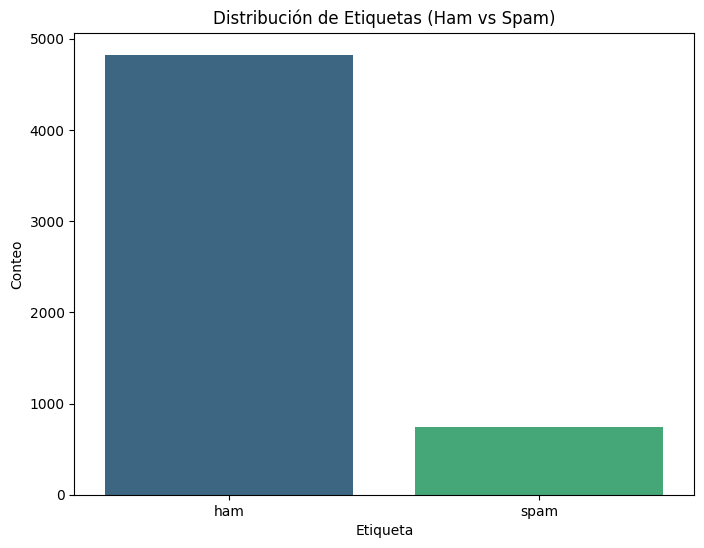

In [108]:
# Mostramos la distribución de las etiquetas
plt.figure(figsize=(8,6))
sns.countplot(x=df['label'], palette='viridis', order = df['label'].value_counts().index)
plt.title('Distribución de Etiquetas (Ham vs Spam)')
plt.xlabel('Etiqueta')
plt.ylabel('Conteo')
plt.show()

## 3. Preprocesamiento de los datos

Antes de vectorizar los textos y entrenar los modelos, es necesario realizar un preprocesamiento de los datos. En este apartado se realizará la limpieza de los textos, eliminando caracteres especiales, números, stopwords, etc.

In [109]:
def limpiar_tweet(tweet):
    # Convertir a string
    tweet = str(tweet)

    # Eliminar URLs
    tweet = re.sub(r'http\S+', '', tweet)

    # Eliminar menciones y hashtags
    tweet = re.sub(r'@[A-Za-z0-9_]+|#[A-Za-z0-9_]+', '', tweet)

    # Eliminar caracteres especiales, números, and signos de puntuación
    tweet = re.sub(r'[^A-Za-z\s]', '', tweet)

    # Eliminar indicador de 'RT' (Retweet)
    tweet = re.sub(r'\bRT\b', '', tweet)

    # Reemplazamos contracciones
    tweet = re.sub(r"won\'t", "would not", tweet)
    tweet = re.sub(r"im", "i am", tweet)
    tweet = re.sub(r"Im", "I am", tweet)
    tweet = re.sub(r"can\'t", "can not", tweet)
    tweet = re.sub(r"don\'t", "do not", tweet)
    tweet = re.sub(r"shouldn\'t", "should not", tweet)
    tweet = re.sub(r"needn\'t", "need not", tweet)
    tweet = re.sub(r"hasn\'t", "has not", tweet)
    tweet = re.sub(r"haven\'t", "have not", tweet)
    tweet = re.sub(r"weren\'t", "were not", tweet)
    tweet = re.sub(r"mightn\'t", "might not", tweet)
    tweet = re.sub(r"didn\'t", "did not", tweet)
    tweet = re.sub(r"n\'t", " not", tweet)
    tweet = re.sub(r"\'re", " are", tweet)
    tweet = re.sub(r"\'s", " is", tweet)
    tweet = re.sub(r"\'d", " would", tweet)
    tweet = re.sub(r"\'ll", " will", tweet)
    tweet = re.sub(r"\'t", " not",tweet)
    tweet = re.sub(r"\'ve", " have", tweet)
    tweet = re.sub(r"\'m", " am", tweet)
    tweet = re.sub(r" u ", " you", tweet)

    # Eliminar caracteres especiales
    tweet = re.sub(r'[!]+' , '!' , tweet)
    tweet = re.sub(r'[?]+' , '?' , tweet)
    tweet = re.sub(r'[.]+' , '.' , tweet)
    tweet = re.sub(r'[@]+' , '@' , tweet)
    tweet = re.sub(r'unk' , ' ' , tweet)
    tweet = re.sub('\n', '', tweet)

    # Convertir a minúsculas y eliminar espacios extra
    tweet = tweet.lower()
    tweet = re.sub(r'[ ]+' , ' ' , tweet)

    # Eliminar stopwords
    stop_words = set(stopwords.words('english'))
    tweet_tokens = nltk.word_tokenize(tweet)
    tweet = ' '.join([word for word in tweet_tokens if word not in stop_words])

    # Lematización
    doc = nlp(tweet)
    # Lematizar cada token y juntarlos de nuevo en un string
    tweet = ' '.join([token.lemma_ for token in doc])

    return tweet

In [110]:
# Plot some stopwords
stopwords.words('english')[:10]

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']

In [111]:
# Aplicamos el preprocesamiento a los tweets
df['message_clean'] = df['message'].apply(limpiar_tweet)

In [112]:
df.sample(5)

,label,message,message_clean
2122,ham,Do you know when the result.,know result
3730,ham,"Isn't frnd a necesity in life? imagine urself witout a frnd.. hw'd u feel at ur colleg? wat'll u do wth ur cell? wat abt functions? thnk abt events espe'll cared, missed &amp; irritated u? 4wrd it to all those dear-loving frnds wthout whom u cant live.. I jst did it.. Takecare..:) GOODMORNING",be not frnd necesity life amagine urself witout frnd hwd youfeel ur colleg watll youdo wth ur cell wat abt function thnk abt event espell care miss amp irritated youwrd dearlove frnd wthout youcant live jst takecare goodmorning
1539,ham,You're not sure that I'm not trying to make xavier smoke because I don't want to smoke after being told I smoke too much?,you re sure try make xavier smoke do not want smoke tell smoke much
3535,ham,Oic cos me n my sis got no lunch today my dad went out... So dunno whether 2 eat in sch or wat...,oic cos n sis get lunch today dad go dunno whether eat sch wat
1401,ham,Kaiez... Enjoy ur tuition... Gee... Thk e second option sounds beta... I'll go yan jiu den msg u...,kaiez enjoy ur tuition gee thk e second option sound beta ill go yan jiu den msg u


In [113]:
df.to_csv('df_clean.csv', index=False)

In [114]:
# Leer dataset limpios para evitar volver a ejecutar el preprocesamiento
df = pd.read_csv('./df_clean.csv')

In [115]:
# Print number of rows with empty values in any column
print(f"El dataset tiene {df.isnull().any(axis=1).sum()} filas con valores nulos")

# Eliminamos filas vacías del DataFrame principal para asegurar que todo el procesamiento posterior esté limpio
df = df.dropna()

El dataset tiene 6 filas con valores nulos


## 4. Wordclouds

Aquí se mostrarán las nubes de palabras para cada clase: ham y spam.

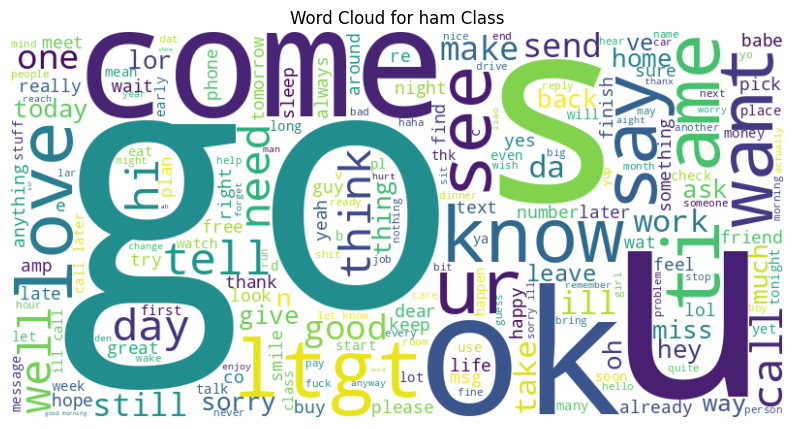

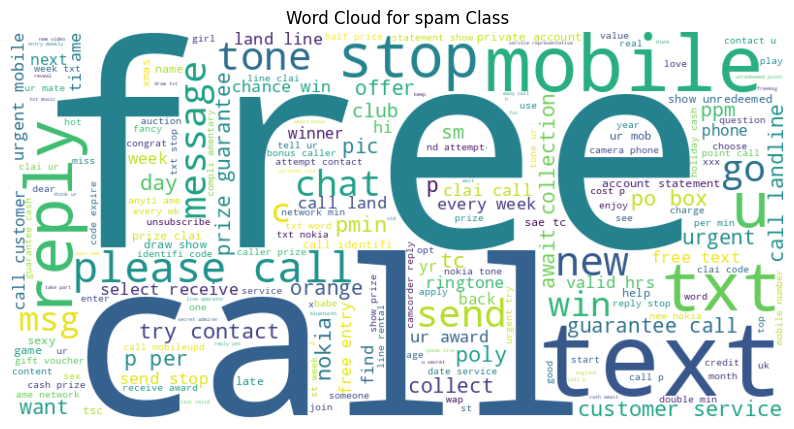

In [116]:
# Generate word clouds for each class
for label in ['ham','spam']:
    # Filter the data for the current class
    data = df[df['label'] == label]['message_clean']

    # Concatenate all the text data into a single string, filling any NaN values with empty strings
    text = ' '.join(data.fillna(''))

    # Create a word cloud object
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    # Plot the word cloud
    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud for {label} Class')
    plt.axis('off')
    plt.show()

Vemos como para el sentimiento positivo hay palabras como 'good', 'great' o 'love. Para el negativo en cambio hay palabras como 'fuck', 'shit' o 'bad'

## 5. Word Embeddings

Representamos los textos como vectores numéricos para que sean entendidas por la máquinas y así nos sirvan como entrada a los modelos. Usaremos TF-IDF y word2vec.

5.1 TF-IDF

En este apartado representaremos los textos con TF-IDF. Sabemos que es un tipo de representación que cuenta la frecuencia de las palabras en un corpus. La idea detrás de TF-IDF es identificar la relevancia de una palabra no solo por su frecuencia en un documento individual (TF), sino también por la rareza de la palabra en todo el corpus (IDF).

5.2 Word2Vec

En este apartado cargaremos un modelo Word2Vec preentrenado para representar los textos como vectores numéricos. Word2Vec es una técnica que permite aprender representaciones vectoriales de palabras, donde palabras con significados similares tienen representaciones similares.

In [124]:
# Create an instance of TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the 'message_clean' column
tfidf_encoded = tfidf_vectorizer.fit_transform(df['message_clean'])

# Print an example
print(f'El tweet "{df.message_clean[10]}" se codifica como:\n{tfidf_encoded[10]}')

# Load pre-trained Word2Vec embeddings
print('Cargando Word2Vec pre-entrenado...')
word_vectors = gensim.downloader.load('glove-wiki-gigaword-100')
print('Word2Vec cargado correctamente.')

El tweet "go to home soon do not want talk stuff anymore tonight k I ve cry enough today" se codifica como:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 15 stored elements and shape (1, 7659)>
  Coords	Values
  (0, 2507)	0.16131681075184076
  (0, 1742)	0.17600713149892955
  (0, 4282)	0.15473243057859393
  (0, 6438)	0.26058297220007065
  (0, 2849)	0.21903046956487435
  (0, 5808)	0.26503633976390284
  (0, 6907)	0.20419766003665346
  (0, 6195)	0.268251566883146
  (0, 6042)	0.27942684766576487
  (0, 344)	0.36375671569496454
  (0, 6484)	0.2666171547998526
  (0, 6795)	0.2460098484013749
  (0, 1440)	0.3701943361228539
  (0, 1965)	0.30003415406424255
  (0, 6445)	0.22407669670871858
Cargando Word2Vec pre-entrenado...
[==================================================] 100.0% 128.1/128.1MB downloaded
Word2Vec cargado correctamente.


## 6. División del conjunto de datos

In [125]:
# Split the dataset into training and testing sets
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

print(f"df_train shape: {df_train.shape}")
print(f"df_test shape: {df_test.shape}")

df_train shape: (4452, 3)
df_test shape: (1114, 3)


In [126]:
# Mostramos el número de filas y columnas
print(f"El dataset de entrenamiento tiene {df_train.shape[0]} filas y el de test tiene {df_test.shape[0]} filas")

El dataset de entrenamiento tiene 4452 filas y el de test tiene 1114 filas


## 6. Análisis (clasificación de texto)

En este apartado se entrenarán varios modelos de clasificación de texto para predecir el sentimiento de los tweets. Se utilizarán tres tipos de modelos: una red neuronal feedforward, una red neuronal recurrente (LSTM) y un modelo preentrenado (BERT). Se compararán los resultados de los tres modelos.

### 6.1 Word2vec + Red Neuronal Feedforward

Entrenaremos una red neuronal feedforward para clasificar los tweets en las categorías de sentimiento. Usaremos una capa de embedding para representar los textos como vectores numéricos con el word2vec entrenado y una capa densa para la clasificación.

In [128]:
# Filtrar el dataset para que solo contenga las clases 'ham' y 'spam'
df_train = df_train[df_train['label'].isin(['ham', 'spam'])]

# Mapear las etiquetas a valores numéricos
df_train['label'] = df_train['label'].map({'ham': 1, 'spam': 0})  # Binary encoding

# Asignamos la variable a predecir 'label' como 'y'
y = df_train['label'].values  # Ensure y is a numpy array of numerical type

In [129]:
# Tokenizamos los textos y los convertimos a secuencias (asignamos X)
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df_train['message_clean'].values)
sequences = tokenizer.texts_to_sequences(df_train['message_clean'].values)
X = pad_sequences(sequences, maxlen=100)

print('Preprocessed text:', df_train['message_clean'].values[100])
print('\nTokenized text:', sequences[100])
print('\nPadded text:', X[100])
print('\nPadded text Length: ', len(X[100]))

Preprocessed text: gud mrng dear hav nice day

Tokenized text: [181, 535, 60, 415, 148, 17]

Padded text: [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0 181 535  60 415 148  17]

Padded text Length:  100


In [130]:
# Preparar la matriz de embeddings
embedding_matrix = np.zeros((len(tokenizer.word_index) + 1, 100))
for word, i in tokenizer.word_index.items():
    if word in word_vectors.key_to_index:  # Updated to use .key_to_index
        embedding_matrix[i] = word_vectors.get_vector(word)

embedding_matrix

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.19103999,  0.17601   ,  0.36919999, ..., -0.59680003,
         0.080843  ,  0.27866   ],
       [ 0.14432999,  0.43950999,  0.58323997, ...,  0.50133997,
         0.49535999,  0.49919999],
       ...,
       [-0.10447   ,  0.77030998,  0.56981999, ...,  0.53293997,
         0.11708   ,  0.25999001],
       [-0.49794   ,  0.010069  , -0.023445  , ...,  0.19812   ,
         0.45543   ,  0.23368999],
       [-0.033499  , -1.13409996, -0.052864  , ..., -0.2059    ,
        -0.70362997,  0.13247   ]])

In [131]:
embedding_matrix.shape

(6850, 100)

In [132]:
# Definir el modelo
model_ffnn = Sequential([
    Embedding(len(tokenizer.word_index) + 1, 100, weights=[embedding_matrix], input_length=100, trainable=False),
    Flatten(),
    Dense(1, activation='sigmoid')
])

# Printear la arquitectura del modelo
model_ffnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │       685,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 685,000 (2.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 685,000 (2.61 MB)

In [133]:
# Compilar el modelo
model_ffnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Ejemplo de entrenamiento del modelo y guardado del historial
history_ffnn = model_ffnn.fit(X, y, epochs=5, validation_split=0.2)

Epoch 1/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8922 - loss: 0.3141 - val_accuracy: 0.9371 - val_loss: 0.2167
Epoch 2/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9542 - loss: 0.1667 - val_accuracy: 0.9473 - val_loss: 0.1748
Epoch 3/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9657 - loss: 0.1319 - val_accuracy: 0.9517 - val_loss: 0.1576
Epoch 4/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9722 - loss: 0.1131 - val_accuracy: 0.9529 - val_loss: 0.1492
Epoch 5/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9761 - loss: 0.0999 - val_accuracy: 0.9529 - val_loss: 0.1408


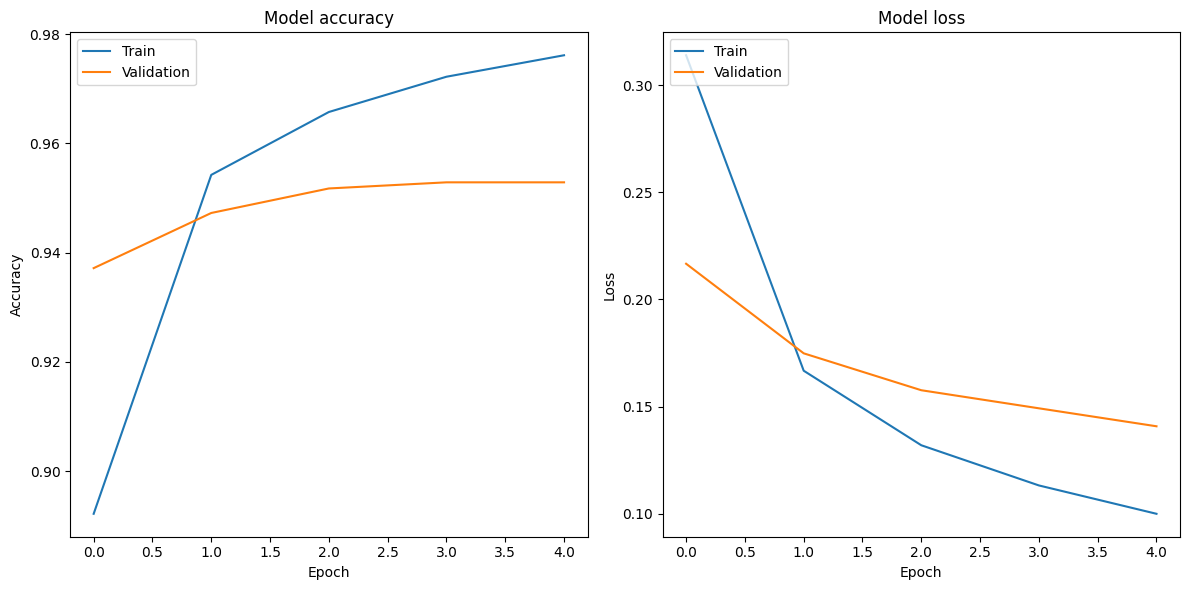

In [134]:
# Assuming 'history' is the result of fitting your model
# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history_ffnn.history['accuracy'])
plt.plot(history_ffnn.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_ffnn.history['loss'])
plt.plot(history_ffnn.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [135]:
def make_prediction(text):
    # Preprocess the example text
    preprocessed_text = limpiar_tweet(text)

    # Tokenize the preprocessed text
    sequence = tokenizer.texts_to_sequences([preprocessed_text])

    # Pad the sequence
    padded_sequence = pad_sequences(sequence, maxlen=100)

    # Make predictions
    predictions = model_ffnn.predict(padded_sequence)

    return predictions

In [141]:
# Example text
example_text1 = "ok, see u home"

# Print the predictions
print(make_prediction(example_text1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
[[0.9913641]]


In [157]:
# Example text
example_text2 = "CALL right now, you have a mobile phone for free. Congrat."

# Print the predictions
print(make_prediction(example_text2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
[[0.7487389]]


### 6.2 Word2vec + Modelos Secuenciales (LSTM)

En este bloque entrenaremos un modelo secuencial, en concreto un LSTM, para clasificar los sentimientos de los tweets. La capa de embeddings será inicializada con los embeddings de word2vec.

In [143]:
# Define LSTM model
model_lstm = Sequential([
    Embedding(len(tokenizer.word_index) + 1, 100, weights=[embedding_matrix], input_length=100, trainable=False),
    LSTM(128),
    Dense(1, activation='sigmoid')
])

# Printear la arquitectura del modelo
model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │       685,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 685,000 (2.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 685,000 (2.61 MB)

In [144]:
# Compilar el modelo
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Ejemplo de entrenamiento del modelo y guardado del historial
history_lstm = model_lstm.fit(X, y, epochs=5, validation_split=0.2)

Epoch 1/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9363 - loss: 0.1968 - val_accuracy: 0.9473 - val_loss: 0.1501
Epoch 2/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9688 - loss: 0.0968 - val_accuracy: 0.9540 - val_loss: 0.1296
Epoch 3/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9705 - loss: 0.0834 - val_accuracy: 0.9517 - val_loss: 0.1270
Epoch 4/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9750 - loss: 0.0759 - val_accuracy: 0.9641 - val_loss: 0.1079
Epoch 5/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9817 - loss: 0.0576 - val_accuracy: 0.9708 - val_loss: 0.1072


### 6.3 TF-IDF + Red Neuronal Feedforward

Entrenaremos una red neuronal feedforward utilizando la representación TF-IDF de los mensajes. Esto nos permitirá ver cómo se comporta un modelo con una representación de frecuencia de términos en comparación con los embeddings pre-entrenados.

In [158]:
# Transformar los mensajes de entrenamiento y prueba usando el TfidfVectorizer ya ajustado
X_train_tfidf = tfidf_vectorizer.transform(df_train['message_clean'])
X_test_tfidf = tfidf_vectorizer.transform(df_test['message_clean'])

# Convertir las matrices dispersas a densas si es necesario para el modelo (Keras Sequential prefiere entradas densas)
X_train_tfidf_dense = X_train_tfidf.toarray()
X_test_tfidf_dense = X_test_tfidf.toarray()

print(f"Shape de X_train_tfidf_dense: {X_train_tfidf_dense.shape}")
print(f"Shape de X_test_tfidf_dense: {X_test_tfidf_dense.shape}")


Shape de X_train_tfidf_dense: (4452, 7659)
Shape de X_test_tfidf_dense: (1114, 7659)


In [159]:
# Definir el modelo FFNN para TF-IDF
model_tfidf_ffnn = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_tfidf_dense.shape[1],)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compilar el modelo
model_tfidf_ffnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Printear la arquitectura del modelo
model_tfidf_ffnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │       980,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 988,801 (3.77 MB)

 Trainable params: 988,801 (3.77 MB)

 Non-trainable params: 0 (0.00 B)

In [160]:
# Entrenar el modelo FFNN con TF-IDF
history_tfidf_ffnn = model_tfidf_ffnn.fit(X_train_tfidf_dense, y, epochs=10, validation_split=0.2, batch_size=32)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8562 - loss: 0.3941 - val_accuracy: 0.8451 - val_loss: 0.2302
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9497 - loss: 0.1301 - val_accuracy: 0.9663 - val_loss: 0.1151
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9876 - loss: 0.0485 - val_accuracy: 0.9764 - val_loss: 0.0951
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9944 - loss: 0.0231 - val_accuracy: 0.9742 - val_loss: 0.0961
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9972 - loss: 0.0125 - val_accuracy: 0.9742 - val_loss: 0.1000
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9986 - loss: 0.0070 - val_accuracy: 0.9731 - val_loss: 0.1142
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9992 - loss: 0.0052 - val_accuracy: 0.9742 - val_loss: 0.1164
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9994 - loss: 0.0036 - val_accuracy: 0

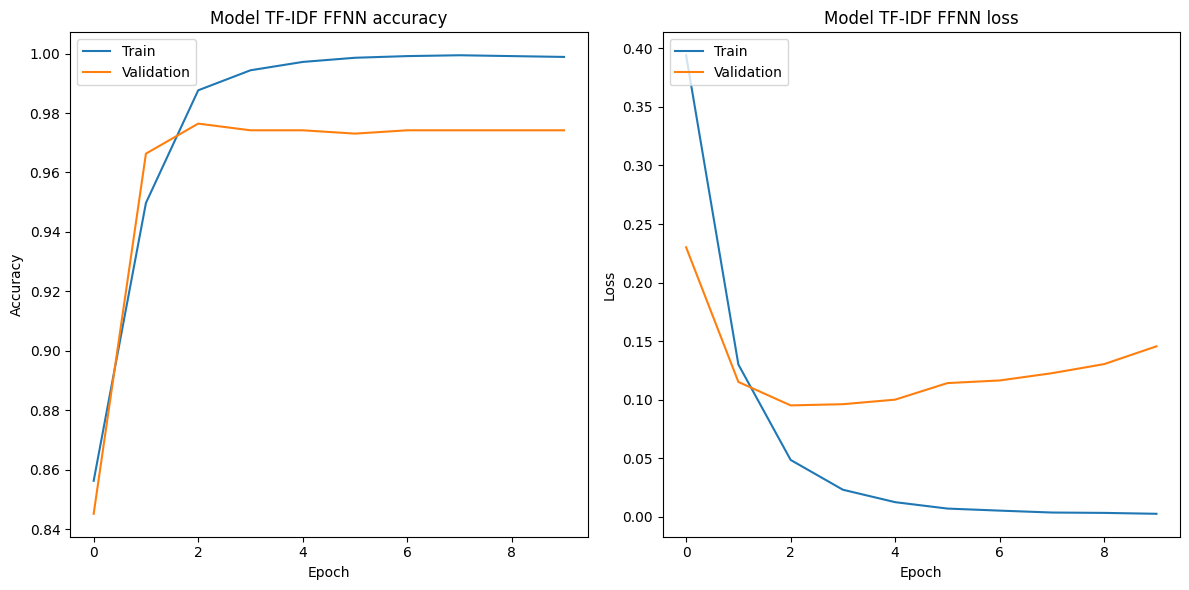

In [161]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history_tfidf_ffnn.history['accuracy'])
plt.plot(history_tfidf_ffnn.history['val_accuracy'])
plt.title('Model TF-IDF FFNN accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_tfidf_ffnn.history['loss'])
plt.plot(history_tfidf_ffnn.history['val_loss'])
plt.title('Model TF-IDF FFNN loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [162]:
def make_prediction_tfidf(text):
    # Preprocess the example text
    preprocessed_text = limpiar_tweet(text)

    # Transform the preprocessed text using the fitted TfidfVectorizer
    tfidf_vector = tfidf_vectorizer.transform([preprocessed_text])

    # Convert to dense array for prediction
    tfidf_vector_dense = tfidf_vector.toarray()

    # Make predictions
    predictions = model_tfidf_ffnn.predict(tfidf_vector_dense)

    return predictions

In [163]:
# Example text
example_text1 = "ok, see u home"

# Print the predictions
print(make_prediction_tfidf(example_text1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
[[0.9999927]]


In [164]:
# Example text
example_text2 = "CALL right now, you have a mobile phone for free. Congrat."

# Print the predictions
print(make_prediction_tfidf(example_text2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
[[0.8163847]]


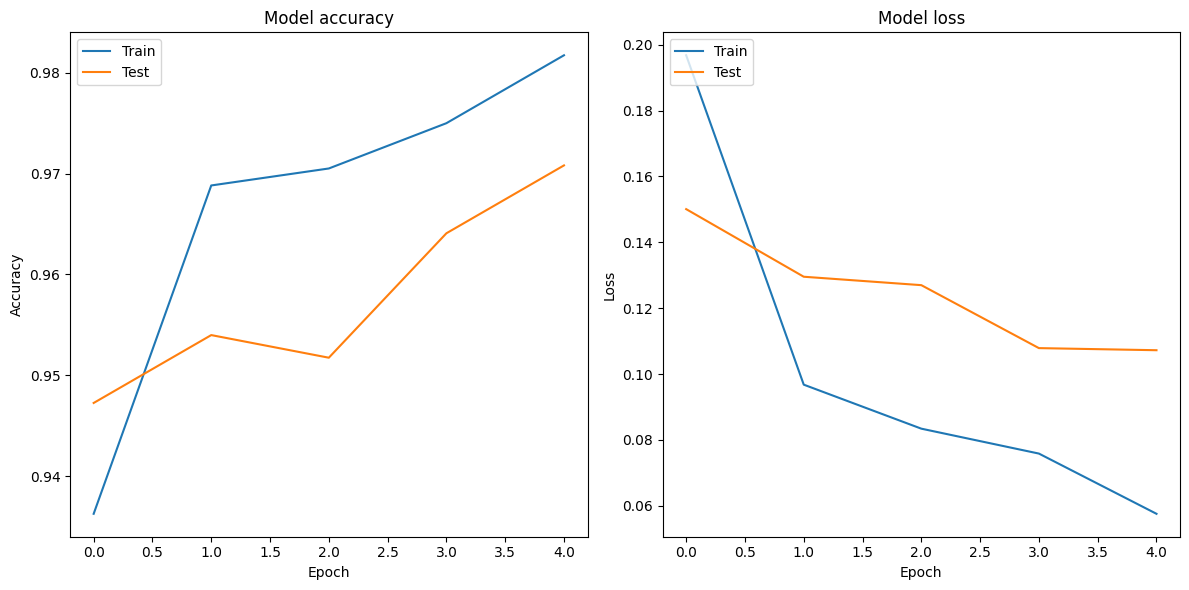

In [145]:
# Assuming 'history' is the result of fitting your model
# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['accuracy'])
plt.plot(history_lstm.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.tight_layout()
plt.show()

In [151]:
def make_prediction2(text):
    # Preprocess the example text
    preprocessed_text = limpiar_tweet(text)

    # Tokenize the preprocessed text
    sequence = tokenizer.texts_to_sequences([preprocessed_text])

    # Pad the sequence
    padded_sequence = pad_sequences(sequence, maxlen=100)

    # Make predictions
    predictions = model_lstm.predict(padded_sequence)

    return predictions

In [152]:
# Example text
example_text1 = "ok, see u home"

# Print the predictions
print(make_prediction2(example_text1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
[[0.9990651]]


In [156]:
# Example text
example_text2 = "CALL right now, you have a mobile phone for free. Congrat."

# Print the predictions
print(make_prediction2(example_text2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
[[0.14333296]]


### 6.4 Comparar resultados de los dos modelos entrenados (FFNN y LSTM)

En este apartado se compararán los resultados de los dos modelos entrenados: la red neuronal feedforward y el modelo secuencial (LSTM). Se mostrarán las matrices de confusión para cada modelo y se calcularán las métricas de evaluación.

In [146]:
# Filtrar el dataset para que solo contenga las clases 'ham' y 'spam'
df_test = df_test[df_test['label'].isin(['ham', 'spam'])]

# Preparamos los datos de test
sequences_test = tokenizer.texts_to_sequences(df_test['message_clean'].values)
X_test = pad_sequences(sequences_test, maxlen=100)
X_test = X_test.astype('float32')
y_test = df_test['label'].map({'ham': 1, 'spam': 0}).values.astype('float32')

In [147]:
# Evaluamos el modelo ffnn en los datos de test
loss_ffnn, accuracy_ffnn = model_ffnn.evaluate(X_test, y_test)

# Evaluamos el modelo lstm en los datos de test
loss_lstm, accuracy_lstm = model_lstm.evaluate(X_test, y_test)

print(f"Accuracy of model_ffnn: {accuracy_ffnn}")
print(f"Accuracy of model_lstm: {accuracy_lstm}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9479 - loss: 0.1496
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9731 - loss: 0.0961
Accuracy of model_ffnn: 0.9479353427886963
Accuracy of model_lstm: 0.9730700254440308


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


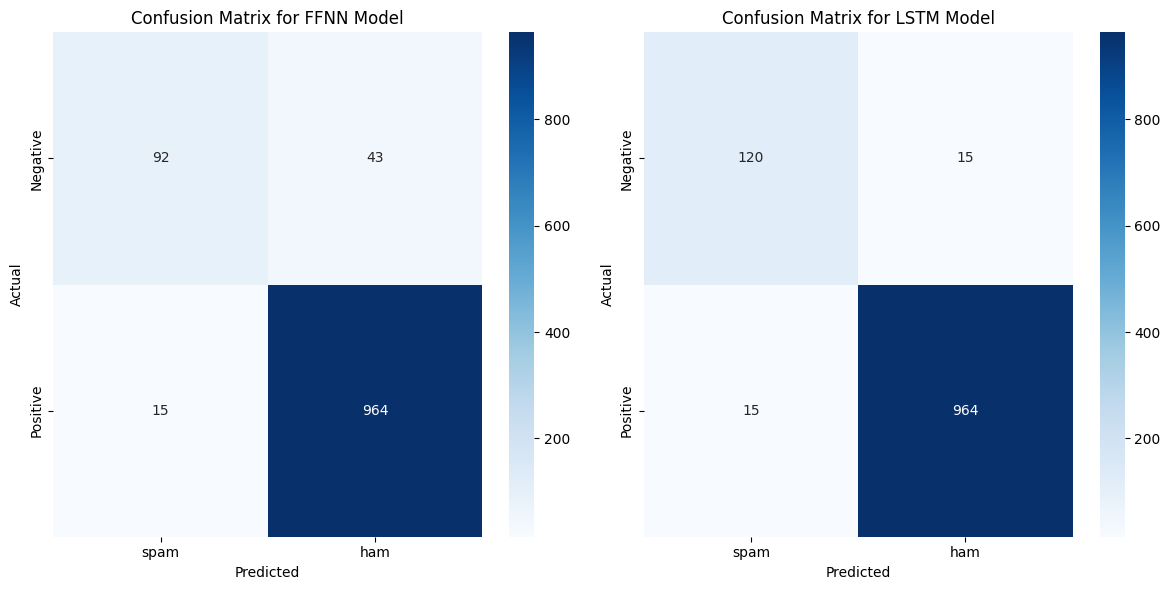

In [167]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Get the predictions for model_ffnn
y_pred_ffnn = model_ffnn.predict(X_test)
y_pred_ffnn = (y_pred_ffnn > 0.5).astype(int)

# Get the predictions for model_lstm
y_pred_lstm = model_lstm.predict(X_test)
y_pred_lstm = (y_pred_lstm > 0.5).astype(int)

# Compute the confusion matrix for model_ffnn
cm_ffnn = confusion_matrix(y_test, y_pred_ffnn)

# Compute the confusion matrix for model_lstm
cm_lstm = confusion_matrix(y_test, y_pred_lstm)

# Plot both confusion matrices side by side
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.heatmap(cm_ffnn, annot=True, fmt='g', cmap='Blues', xticklabels=['spam', 'ham'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for FFNN Model')

plt.subplot(1, 2, 2)
sns.heatmap(cm_lstm, annot=True, fmt='g', cmap='Blues', xticklabels=['spam', 'ham'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for LSTM Model')

plt.tight_layout()


In [168]:
# Print classification report for model_ffnn
print("Classification Report for FFNN Model (Word2Vec):")
print(classification_report(y_test, y_pred_ffnn))

# Print classification report for model_lstm
print("\nClassification Report for LSTM Model (Word2Vec):")
print(classification_report(y_test, y_pred_lstm))

Classification Report for FFNN Model (Word2Vec):
              precision    recall  f1-score   support

         0.0       0.86      0.68      0.76       135
         1.0       0.96      0.98      0.97       979

    accuracy                           0.95      1114
   macro avg       0.91      0.83      0.87      1114
weighted avg       0.95      0.95      0.95      1114


Classification Report for LSTM Model (Word2Vec):
              precision    recall  f1-score   support

         0.0       0.89      0.89      0.89       135
         1.0       0.98      0.98      0.98       979

    accuracy                           0.97      1114
   macro avg       0.94      0.94      0.94      1114
weighted avg       0.97      0.97      0.97      1114



In [165]:
# Evaluamos el modelo FFNN con TF-IDF en los datos de test
loss_tfidf_ffnn, accuracy_tfidf_ffnn = model_tfidf_ffnn.evaluate(X_test_tfidf_dense, y_test)

print(f"Accuracy of model_ffnn (Word2Vec): {accuracy_ffnn}")
print(f"Accuracy of model_lstm (Word2Vec): {accuracy_lstm}")
print(f"Accuracy of model_tfidf_ffnn (TF-IDF): {accuracy_tfidf_ffnn}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9820 - loss: 0.0960
Accuracy of model_ffnn (Word2Vec): 0.9479353427886963
Accuracy of model_lstm (Word2Vec): 0.9730700254440308
Accuracy of model_tfidf_ffnn (TF-IDF): 0.9820466637611389


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


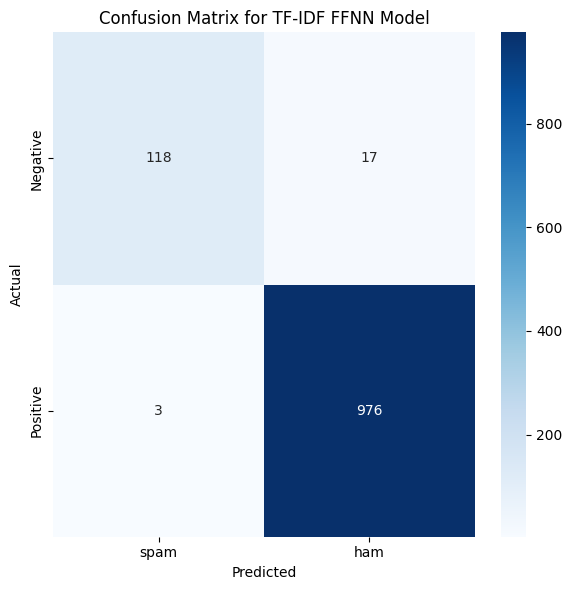

In [166]:
# Get the predictions for model_tfidf_ffnn
y_pred_tfidf_ffnn = model_tfidf_ffnn.predict(X_test_tfidf_dense)
y_pred_tfidf_ffnn = (y_pred_tfidf_ffnn > 0.5).astype(int)

# Compute the confusion matrix for model_tfidf_ffnn
cm_tfidf_ffnn = confusion_matrix(y_test, y_pred_tfidf_ffnn)

# Plot the confusion matrix for the TF-IDF FFNN Model
plt.figure(figsize=(6, 6))
sns.heatmap(cm_tfidf_ffnn, annot=True, fmt='g', cmap='Blues', xticklabels=['spam', 'ham'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for TF-IDF FFNN Model')
plt.tight_layout()
plt.show()

In [169]:
# Print classification report for model_tfidf_ffnn
print("Classification Report for TF-IDF FFNN Model:")
print(classification_report(y_test, y_pred_tfidf_ffnn))

Classification Report for TF-IDF FFNN Model:
              precision    recall  f1-score   support

         0.0       0.98      0.87      0.92       135
         1.0       0.98      1.00      0.99       979

    accuracy                           0.98      1114
   macro avg       0.98      0.94      0.96      1114
weighted avg       0.98      0.98      0.98      1114



Evaluación y comparación: Evaluamos el rendimiento de cada modelo utilizando métricas de precisión, recall, F1-score y matrices de confusión en el conjunto de prueba. Los resultados destacaron que el Modelo de Red Neuronal Feedforward con TF-IDF obtuvo la mejor precisión (aproximadamente 0.982), superando al LSTM con Word2Vec (0.973) y al FFNN con Word2Vec (0.948).

Este análisis proporciona una visión clara de cómo diferentes técnicas de representación de texto y arquitecturas de modelos pueden impactar la capacidad de clasificar mensajes SMS como spam o ham.